In [32]:
# 2. Create and export a column_metadata.json file programmatically
column_metadata = {
    "column_details": {
        "student_id": {"type": "int", "description": "Unique identifier for each student"},
        "gender": {"type": "category", "allowed_values": ["Male", "Female", "Other"], "description": "Gender of the student"},
        "age": {"type": "int", "description": "Age of the student"},
        "school_type": {"type": "category", "allowed_values": ["Public", "Private"], "description": "Type of school (Public or Private)"},
        "parent_education": {"type": "category", "allowed_values": ["None", "High School", "Some College", "Bachelors", "Masters", "PhD"], "description": "Highest education level of parents"},
        "family_income": {"type": "category", "allowed_values": ["Low", "Medium", "High"], "description": "Family income level"},
        "study_hours_per_day": {"type": "float", "min": 0.0, "max": 24.0, "description": "Number of hours studied per day"},
        "previous_exam_score": {"type": "int", "min": 0, "max": 100, "description": "Score from a previous exam"},
        "previous_gpa": {"type": "float", "min": 0.0, "max": 4.0, "description": "Grade Point Average from previous academic year"},
        "attendance_percentage": {"type": "float", "min": 0.0, "max": 100.0, "description": "Percentage of class attendance"},
        "tuition_fees": {"type": "int", "description": "Tuition fees paid by the student"},
        "extracurricular_activities": {"type": "bool", "description": "Whether the student participates in extracurricular activities"},
        "study_method": {"type": "category", "allowed_values": ["Group Study", "Self-Study", "Online Learning", "Tutoring"], "description": "Preferred study method"},
        "sleep_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Number of hours student sleeps per night"},
        "notes_quality": {"type": "category", "allowed_values": ["Poor", "Average", "Good", "Excellent"], "description": "Quality of notes taken by student"},
        "assignment_completion": {"type": "float", "min": 0.0, "max": 100.0, "description": "Percentage of assignments completed"},
        "feedback_score": {"type": "int", "min": 1, "max": 5, "description": "Feedback score from teachers"},
        "parent_support_score": {"type": "int", "min": 1, "max": 5, "description": "Score indicating parental support"},
        "teacher_engagement_score": {"type": "int", "min": 1, "max": 5, "description": "Score indicating teacher engagement"},
        "internet_access": {"type": "bool", "description": "Whether the student has internet access at home"},
        "device_availability": {"type": "category", "allowed_values": ["None", "Smartphone", "Laptop", "Tablet"], "description": "Availability of personal electronic devices"},
        "financial_aid": {"type": "bool", "description": "Whether the student receives financial aid"},
        "disability": {"type": "bool", "description": "Whether the student has a disability"},
        "transport_time": {"type": "int", "description": "Time taken to travel to school (in minutes)"},
        "meal_quality": {"type": "category", "allowed_values": ["Poor", "Average", "Good", "Excellent"], "description": "Quality of meals consumed"},
        "social_media_usage": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on social media per day"},
        "time_management_score": {"type": "int", "min": 0, "max": 100, "description": "Score reflecting student's time management skills"},
        "group_study_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent in group study sessions"},
        "self_study_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on self-study"},
        "online_learning_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on online learning platforms"},
        "library_visits": {"type": "int", "description": "Number of library visits per month"},
        "sports_participation": {"type": "bool", "description": "Whether the student participates in sports"},
        "part_time_job": {"type": "bool", "description": "Whether the student has a part-time job"},
        "health_issues": {"type": "bool", "description": "Whether the student has health issues"},
        "mentor_support": {"type": "bool", "description": "Whether the student receives mentor support"},
        "questions_attempted": {"type": "int", "min": 0, "description": "Number of questions attempted in the exam"},
        "questions_correct": {"type": "int", "min": 0, "description": "Number of questions answered correctly in the exam"},
        "exam_score": {"type": "int", "min": 0, "max": 100, "description": "Final exam score"},
        "exam_difficulty": {"type": "category", "allowed_values": ["Easy", "Medium", "Hard"], "description": "Difficulty level of the exam"},
        "previous_grade": {"type": "category", "allowed_values": ["A", "B", "C", "D", "F"], "description": "Grade from previous academic term"},
        "stress_level": {"type": "int", "min": 1, "max": 10, "description": "Student's self-reported stress level"},
        "motivation_level": {"type": "int", "min": 1, "max": 10, "description": "Student's self-reported motivation level"},
        "daily_screen_time": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on screens daily (excluding study)"},
        "sleep_quality": {"type": "category", "allowed_values": ["Poor", "Average", "Good", "Excellent"], "description": "Self-reported sleep quality"},
        "performance_grade": {"type": "category", "allowed_values": ["A", "B", "C", "D", "F"], "description": "Overall performance grade (A, B, C, D, F)"},
        "pass_status": {"type": "category", "allowed_values": ["Pass", "Fail"], "description": "Pass/Fail status in the exam"},
        "performance_level": {"type": "category", "allowed_values": ["Excellent", "Good", "Average", "Below Average", "Poor"], "description": "Detailed performance level"}
    },
    "missing_value_strategy": {
        "numerical_imputation_group_by": "performance_grade",
        "numerical_imputation_method": "median",
        "categorical_imputation_method": "mode_or_unknown",
        "categorical_unknown_label": "Unknown"
    },
    "thresholds": {
        "high_risk_attendance_pct": 75.0,
        "high_risk_gpa": 2.5
    }
}

metadata_filepath = 'data/raw/column_metadata.json'
with open(metadata_filepath, 'w') as f:
    json.dump(column_metadata, f, indent=4)

print(f"Column metadata saved to {metadata_filepath}")

Column metadata saved to data/raw/column_metadata.json


## Section 1: Environment Setup & Reference Config (JSON)

In [33]:
# 1. Import all required libraries
import pandas as pd
import numpy as np
import sqlite3
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from pathlib import Path

# Ensure the data directories exist
Path('data/raw').mkdir(parents=True, exist_ok=True)
Path('data/processed').mkdir(parents=True, exist_ok=True)

print("Libraries imported and data directories created.")

Libraries imported and data directories created.


### Create and export `column_metadata.json`

In [34]:
# Define column_metadata dictionary and save it to a JSON file
metadata_filepath = 'data/raw/column_metadata.json'

column_metadata = {
    "column_details": {
        "student_id": {"type": "int", "description": "Unique identifier for each student"},
        "gender": {"type": "category", "allowed_values": ["Male", "Female", "Other"], "description": "Gender of the student"},
        "age": {"type": "int", "description": "Age of the student"},
        "school_type": {"type": "category", "allowed_values": ["Public", "Private"], "description": "Type of school (Public or Private)"},
        "parent_education": {"type": "category", "allowed_values": ["None", "High School", "Some College", "Bachelors", "Masters", "PhD"], "description": "Highest education level of parents"},
        "family_income": {"type": "category", "allowed_values": ["Low", "Medium", "High"], "description": "Family income level"},
        "study_hours_per_day": {"type": "float", "min": 0.0, "max": 24.0, "description": "Number of hours studied per day"},
        "previous_exam_score": {"type": "int", "min": 0, "max": 100, "description": "Score from a previous exam"},
        "previous_gpa": {"type": "float", "min": 0.0, "max": 4.0, "description": "Grade Point Average from previous academic year"},
        "attendance_percentage": {"type": "float", "min": 0.0, "max": 100.0, "description": "Percentage of class attendance"},
        "tuition_fees": {"type": "int", "description": "Tuition fees paid by the student"},
        "extracurricular_activities": {"type": "bool", "description": "Whether the student participates in extracurricular activities"},
        "study_method": {"type": "category", "allowed_values": ["Group Study", "Self-Study", "Online Learning", "Tutoring"], "description": "Preferred study method"},
        "sleep_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Number of hours student sleeps per night"},
        "notes_quality": {"type": "category", "allowed_values": ["Poor", "Average", "Good", "Excellent"], "description": "Quality of notes taken by student"},
        "assignment_completion": {"type": "float", "min": 0.0, "max": 100.0, "description": "Percentage of assignments completed"},
        "feedback_score": {"type": "int", "min": 1, "max": 5, "description": "Feedback score from teachers"},
        "parent_support_score": {"type": "int", "min": 1, "max": 5, "description": "Score indicating parental support"},
        "teacher_engagement_score": {"type": "int", "min": 1, "max": 5, "description": "Score indicating teacher engagement"},
        "internet_access": {"type": "bool", "description": "Whether the student has internet access at home"},
        "device_availability": {"type": "category", "allowed_values": ["None", "Smartphone", "Laptop", "Tablet"], "description": "Availability of personal electronic devices"},
        "financial_aid": {"type": "bool", "description": "Whether the student receives financial aid"},
        "disability": {"type": "bool", "description": "Whether the student has a disability"},
        "transport_time": {"type": "int", "description": "Time taken to travel to school (in minutes)"},
        "meal_quality": {"type": "category", "allowed_values": ["Poor", "Average", "Good", "Excellent"], "description": "Quality of meals consumed"},
        "social_media_usage": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on social media per day"},
        "time_management_score": {"type": "int", "min": 0, "max": 100, "description": "Score reflecting student's time management skills"},
        "group_study_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent in group study sessions"},
        "self_study_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on self-study"},
        "online_learning_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on online learning platforms"},
        "library_visits": {"type": "int", "description": "Number of library visits per month"},
        "sports_participation": {"type": "bool", "description": "Whether the student participates in sports"},
        "part_time_job": {"type": "bool", "description": "Whether the student has a part-time job"},
        "health_issues": {"type": "bool", "description": "Whether the student has health issues"},
        "mentor_support": {"type": "bool", "description": "Whether the student receives mentor support"},
        "questions_attempted": {"type": "int", "min": 0, "description": "Number of questions attempted in the exam"},
        "questions_correct": {"type": "int", "min": 0, "description": "Number of questions answered correctly in the exam"},
        "exam_score": {"type": "int", "min": 0, "max": 100, "description": "Final exam score"},
        "exam_difficulty": {"type": "category", "allowed_values": ["Easy", "Medium", "Hard"], "description": "Difficulty level of the exam"},
        "previous_grade": {"type": "category", "allowed_values": ["A", "B", "C", "D", "F"], "description": "Grade from previous academic term"},
        "stress_level": {"type": "int", "min": 1, "max": 10, "description": "Student's self-reported stress level"},
        "motivation_level": {"type": "int", "min": 1, "max": 10, "description": "Student's self-reported motivation level"},
        "daily_screen_time": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on screens daily (excluding study)"},
        "sleep_quality": {"type": "category", "allowed_values": ["Poor", "Average", "Good", "Excellent"], "description": "Self-reported sleep quality"},
        "performance_grade": {"type": "category", "allowed_values": ["A", "B", "C", "D", "F"], "description": "Overall performance grade (A, B, C, D, F)"},
        "pass_status": {"type": "category", "allowed_values": ["Pass", "Fail"], "description": "Pass/Fail status in the exam"},
        "performance_level": {"type": "category", "allowed_values": ["Excellent", "Good", "Average", "Below Average", "Poor"], "description": "Detailed performance level"}
    },
    "missing_value_strategy": {
        "numerical_imputation_group_by": "performance_grade",
        "numerical_imputation_method": "median",
        "categorical_imputation_method": "mode_or_unknown",
        "categorical_unknown_label": "Unknown"
    },
    "thresholds": {
        "high_risk_attendance_pct": 75.0,
        "high_risk_gpa": 2.5
    }
}

# Export the column_metadata to a JSON file
with open(metadata_filepath, 'w') as f:
    json.dump(column_metadata, f, indent=4)

print(f"Column metadata definition exported to {metadata_filepath}")

Column metadata definition exported to data/raw/column_metadata.json


In [35]:
# 2. Create and export a column_metadata.json file programmatically
column_metadata = {
    "column_details": {
        "student_id": {"type": "int", "description": "Unique identifier for each student"},
        "gender": {"type": "category", "allowed_values": ["Male", "Female", "Other"], "description": "Gender of the student"},
        "age": {"type": "int", "description": "Age of the student"},
        "school_type": {"type": "category", "allowed_values": ["Public", "Private"], "description": "Type of school (Public or Private)"},
        "parent_education": {"type": "category", "allowed_values": ["None", "High School", "Some College", "Bachelors", "Masters", "PhD"], "description": "Highest education level of parents"},
        "family_income": {"type": "category", "allowed_values": ["Low", "Medium", "High"], "description": "Family income level"},
        "study_hours_per_day": {"type": "float", "min": 0.0, "max": 24.0, "description": "Number of hours studied per day"},
        "previous_exam_score": {"type": "int", "min": 0, "max": 100, "description": "Score from a previous exam"},
        "previous_gpa": {"type": "float", "min": 0.0, "max": 4.0, "description": "Grade Point Average from previous academic year"},
        "attendance_percentage": {"type": "float", "min": 0.0, "max": 100.0, "description": "Percentage of class attendance"},
        "tuition_fees": {"type": "int", "description": "Tuition fees paid by the student"},
        "extracurricular_activities": {"type": "bool", "description": "Whether the student participates in extracurricular activities"},
        "study_method": {"type": "category", "allowed_values": ["Group Study", "Self-Study", "Online Learning", "Tutoring"], "description": "Preferred study method"},
        "sleep_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Number of hours student sleeps per night"},
        "notes_quality": {"type": "category", "allowed_values": ["Poor", "Average", "Good", "Excellent"], "description": "Quality of notes taken by student"},
        "assignment_completion": {"type": "float", "min": 0.0, "max": 100.0, "description": "Percentage of assignments completed"},
        "feedback_score": {"type": "int", "min": 1, "max": 5, "description": "Feedback score from teachers"},
        "parent_support_score": {"type": "int", "min": 1, "max": 5, "description": "Score indicating parental support"},
        "teacher_engagement_score": {"type": "int", "min": 1, "max": 5, "description": "Score indicating teacher engagement"},
        "internet_access": {"type": "bool", "description": "Whether the student has internet access at home"},
        "device_availability": {"type": "category", "allowed_values": ["None", "Smartphone", "Laptop", "Tablet"], "description": "Availability of personal electronic devices"},
        "financial_aid": {"type": "bool", "description": "Whether the student receives financial aid"},
        "disability": {"type": "bool", "description": "Whether the student has a disability"},
        "transport_time": {"type": "int", "description": "Time taken to travel to school (in minutes)"},
        "meal_quality": {"type": "category", "allowed_values": ["Poor", "Average", "Good", "Excellent"], "description": "Quality of meals consumed"},
        "social_media_usage": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on social media per day"},
        "time_management_score": {"type": "int", "min": 0, "max": 100, "description": "Score reflecting student's time management skills"},
        "group_study_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent in group study sessions"},
        "self_study_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on self-study"},
        "online_learning_hours": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on online learning platforms"},
        "library_visits": {"type": "int", "description": "Number of library visits per month"},
        "sports_participation": {"type": "bool", "description": "Whether the student participates in sports"},
        "part_time_job": {"type": "bool", "description": "Whether the student has a part-time job"},
        "health_issues": {"type": "bool", "description": "Whether the student has health issues"},
        "mentor_support": {"type": "bool", "description": "Whether the student receives mentor support"},
        "questions_attempted": {"type": "int", "min": 0, "description": "Number of questions attempted in the exam"},
        "questions_correct": {"type": "int", "min": 0, "description": "Number of questions answered correctly in the exam"},
        "exam_score": {"type": "int", "min": 0, "max": 100, "description": "Final exam score"},
        "exam_difficulty": {"type": "category", "allowed_values": ["Easy", "Medium", "Hard"], "description": "Difficulty level of the exam"},
        "previous_grade": {"type": "category", "allowed_values": ["A", "B", "C", "D", "F"], "description": "Grade from previous academic term"},
        "stress_level": {"type": "int", "min": 1, "max": 10, "description": "Student's self-reported stress level"},
        "motivation_level": {"type": "int", "min": 1, "max": 10, "description": "Student's self-reported motivation level"},
        "daily_screen_time": {"type": "float", "min": 0.0, "max": 24.0, "description": "Hours spent on screens daily (excluding study)"},
        "sleep_quality": {"type": "category", "allowed_values": ["Poor", "Average", "Good", "Excellent"], "description": "Self-reported sleep quality"},
        "performance_grade": {"type": "category", "allowed_values": ["A", "B", "C", "D", "F"], "description": "Overall performance grade (A, B, C, D, F)"},
        "pass_status": {"type": "category", "allowed_values": ["Pass", "Fail"], "description": "Pass/Fail status in the exam"},
        "performance_level": {"type": "category", "allowed_values": ["Excellent", "Good", "Average", "Below Average", "Poor"], "description": "Detailed performance level"}
    },
    "missing_value_strategy": {
        "numerical_imputation_group_by": "performance_grade",
        "numerical_imputation_method": "median",
        "categorical_imputation_method": "mode_or_unknown",
        "categorical_unknown_label": "Unknown"
    },
    "thresholds": {
        "high_risk_attendance_pct": 75.0,
        "high_risk_gpa": 2.5
    }
}

metadata_filepath = 'data/raw/column_metadata.json'
with open(metadata_filepath, 'w') as f:
    json.dump(column_metadata, f, indent=4)

print(f"Column metadata saved to {metadata_filepath}")

Column metadata saved to data/raw/column_metadata.json


## Section 2: Extract (E)
### Define raw data filepath

In [36]:
# Define the path to the raw data file
raw_data_filepath = '/content/drive/MyDrive/student_exam_performance (2).csv'
print(f"Raw data filepath set to: {raw_data_filepath}")

Raw data filepath set to: /content/drive/MyDrive/student_exam_performance (2).csv


In [37]:
# Download the dataset if it doesn't exist
if not Path(raw_data_filepath).exists():
    print(f"Downloading {Path(raw_data_filepath).name}...")
    # Assuming a public URL for the dataset. Please replace with the actual URL if different.
    # For demonstration, I'll use a placeholder or a common public dataset if available.
    # For this specific file, I'll assume it's available via a direct link, or provide a command to create a dummy one if not.

    # Using a placeholder for now, you might need to adjust this based on the actual dataset source.
    # Example: !wget -P data/raw/ 'https://raw.githubusercontent.com/user/repo/branch/student_exam_performance.csv'

    # For the purpose of making the notebook runnable, let's create a dummy CSV if not found
    print("Note: `student_exam_performance.csv` not found. Creating a dummy CSV for demonstration purposes.")
    dummy_data = {
        'student_id': range(1, 101),
        'gender': np.random.choice(['Male', 'Female'], 100),
        'age': np.random.randint(17, 25, 100),
        'school_type': np.random.choice(['Public', 'Private'], 100),
        'parent_education': np.random.choice(['High School', 'Bachelors', 'Masters', np.nan], 100),
        'family_income': np.random.choice(['Low', 'Medium', 'High'], 100),
        'study_hours_per_day': np.random.uniform(1, 5, 100).round(1),
        'previous_exam_score': np.random.randint(40, 95, 100),
        'previous_gpa': np.random.uniform(2.0, 4.0, 100).round(2),
        'attendance_percentage': np.random.uniform(70, 100, 100).round(1),
        'tuition_fees': np.random.randint(1000, 5000, 100),
        'extracurricular_activities': np.random.choice([True, False], 100),
        'study_method': np.random.choice(['Self-Study', 'Group Study', 'Online Learning'], 100),
        'sleep_hours': np.random.uniform(5, 9, 100).round(1),
        'notes_quality': np.random.choice(['Average', 'Good', 'Excellent', np.nan], 100),
        'assignment_completion': np.random.uniform(60, 100, 100).round(1),
        'feedback_score': np.random.randint(3, 5, 100),
        'parent_support_score': np.random.randint(3, 5, 100),
        'teacher_engagement_score': np.random.randint(3, 5, 100),
        'internet_access': np.random.choice([True, False], 100),
        'device_availability': np.random.choice(['Laptop', 'Smartphone', 'None', np.nan], 100),
        'financial_aid': np.random.choice([True, False], 100),
        'disability': np.random.choice([True, False], 100),
        'transport_time': np.random.randint(5, 60, 100),
        'meal_quality': np.random.choice(['Average', 'Good', 'Excellent'], 100),
        'social_media_usage': np.random.uniform(1, 4, 100).round(1),
        'time_management_score': np.random.randint(50, 90, 100),
        'group_study_hours': np.random.uniform(0, 3, 100).round(1),
        'self_study_hours': np.random.uniform(1, 4, 100).round(1),
        'online_learning_hours': np.random.uniform(0, 2, 100).round(1),
        'library_visits': np.random.randint(0, 5, 100),
        'sports_participation': np.random.choice([True, False], 100),
        'part_time_job': np.random.choice([True, False], 100),
        'health_issues': np.random.choice([True, False], 100),
        'mentor_support': np.random.choice([True, False], 100),
        'questions_attempted': np.random.randint(20, 50, 100),
        'questions_correct': np.random.randint(15, 45, 100),
        'exam_score': np.random.randint(50, 100, 100),
        'exam_difficulty': np.random.choice(['Easy', 'Medium', 'Hard'], 100),
        'previous_grade': np.random.choice(['A', 'B', 'C', 'D', 'F'], 100),
        'stress_level': np.random.randint(1, 10, 100),
        'motivation_level': np.random.randint(5, 10, 100),
        'daily_screen_time': np.random.uniform(2, 8, 100).round(1),
        'sleep_quality': np.random.choice(['Average', 'Good', 'Excellent', np.nan], 100),
        'performance_grade': np.random.choice(['A', 'B', 'C', 'D', 'F'], 100),
        'pass_status': np.random.choice(['Pass', 'Fail'], 100),
        'performance_level': np.random.choice(['Excellent', 'Good', 'Average', 'Below Average', 'Poor'], 100)
    }
    # Ensure 'questions_correct' is always less than or equal to 'questions_attempted'
    for i in range(100):
        if 'questions_attempted' in dummy_data and 'questions_correct' in dummy_data and dummy_data['questions_correct'][i] > dummy_data['questions_attempted'][i]:
            dummy_data['questions_correct'][i] = np.random.randint(0, dummy_data['questions_attempted'][i] + 1)

    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.to_csv(raw_data_filepath, index=False)
    print(f"Dummy dataset created at {raw_data_filepath}")
else:
    print(f"'{Path(raw_data_filepath).name}' already exists. Skipping download.")

'student_exam_performance (2).csv' already exists. Skipping download.


In [23]:
# 1. Read student_exam_performance.csv into a Pandas DataFrame (df_raw)
try:
    df_raw = pd.read_csv(raw_data_filepath)
    print(f"Successfully loaded {raw_data_filepath} into df_raw.")
except FileNotFoundError:
    print(f"Error: The file '{raw_data_filepath}' was not found.")
    print("Please ensure 'student_exam_performance.csv' is in the 'data/raw/' directory.")
    df_raw = None # Assign None to df_raw to indicate failure

Successfully loaded /content/drive/MyDrive/student_exam_performance (2).csv into df_raw.


In [24]:
if df_raw is not None:
    # 2. Display initial shape, column list, data types (df.dtypes), and memory usage
    print("\n--- Initial Data Inspection ---")
    print(f"DataFrame shape: {df_raw.shape}")
    print("\nColumn list:")
    print(df_raw.columns.tolist())
    print("\nData types:")
    print(df_raw.dtypes)
    print("\nMemory usage:")
    print(df_raw.memory_usage(deep=True))

    # 3. Perform an initial inspection (df.head() and df.tail())
    print("\n--- First 5 rows (df.head()) ---")
    print(df_raw.head().to_markdown(index=False, numalign="left", stralign="left"))
    print("\n--- Last 5 rows (df.tail()) ---")
    print(df_raw.tail().to_markdown(index=False, numalign="left", stralign="left"))



--- Initial Data Inspection ---
DataFrame shape: (100000, 44)

Column list:
['student_id', 'age', 'gender', 'education_level', 'school_type', 'family_income', 'parent_education', 'urban_rural', 'previous_exam_score', 'previous_gpa', 'attendance_percentage', 'assignment_completion_rate', 'class_participation', 'study_hours_per_day', 'self_study_hours', 'private_tuition', 'online_learning_hours', 'study_consistency', 'study_environment', 'study_method', 'revision_frequency', 'practice_tests_completed', 'notes_quality', 'sleep_hours', 'sleep_quality', 'daily_screen_time', 'physical_activity_hours', 'break_frequency', 'stress_level', 'motivation_level', 'internet_access', 'device_availability', 'educational_app_usage', 'online_course_hours', 'exam_difficulty', 'exam_preparation_days', 'questions_attempted', 'questions_correct', 'time_management_score', 'exam_anxiety_level', 'exam_score', 'performance_grade', 'pass_status', 'performance_level']

Data types:
student_id                     o

## Section 3: Data Profiling & Anomaly Detection

### 1. Missing / Null Data Analysis

In [25]:
if df_raw is not None:
    print("--- Missing Data Analysis ---")
    missing_data = pd.DataFrame({
        'Missing Count': df_raw.isnull().sum(),
        'Missing Percentage': (df_raw.isnull().sum() / len(df_raw)) * 100
    })
    missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

    if not missing_data.empty:
        print("\nColumns with Missing Values:")
        print(missing_data.to_markdown(numalign="left", stralign="left"))

        # Focus on specified columns
        focus_columns = [
            'parent_education', 'previous_gpa', 'attendance_percentage',
            'notes_quality', 'sleep_quality', 'device_availability', 'time_management_score'
        ]
        focus_missing = missing_data.loc[missing_data.index.intersection(focus_columns)]
        if not focus_missing.empty:
            print("\nMissing Data in Focused Columns:")
            print(focus_missing.to_markdown(numalign="left", stralign="left"))
        else:
            print("No missing values in the specified focus columns.")
    else:
        print("No missing values found in the dataset.")
else:
    print("Raw DataFrame not loaded, skipping missing data analysis.")

--- Missing Data Analysis ---

Columns with Missing Values:
|                       | Missing Count   | Missing Percentage   |
|:----------------------|:----------------|:---------------------|
| attendance_percentage | 9863            | 9.863                |
| time_management_score | 9613            | 9.613                |
| notes_quality         | 8407            | 8.407                |
| previous_gpa          | 7793            | 7.793                |
| sleep_quality         | 6994            | 6.994                |
| parent_education      | 6526            | 6.526                |
| device_availability   | 2965            | 2.965                |

Missing Data in Focused Columns:
|                       | Missing Count   | Missing Percentage   |
|:----------------------|:----------------|:---------------------|
| attendance_percentage | 9863            | 9.863                |
| time_management_score | 9613            | 9.613                |
| notes_quality         | 8407     

### 2. Data Uniformity & Categorical Auditing

In [26]:
if df_raw is not None:
    print("\n--- Categorical Feature Auditing ---")
    categorical_cols = [
        'gender', 'school_type', 'family_income', 'study_method',
        'performance_grade', 'pass_status', 'performance_level'
    ]

    # Filter to only include columns that exist in df_raw
    existing_categorical_cols = [col for col in categorical_cols if col in df_raw.columns]

    if existing_categorical_cols:
        for col in existing_categorical_cols:
            print(f"\nUnique values for '{col}':")
            unique_counts = df_raw[col].value_counts(dropna=False)
            print(unique_counts.to_markdown(numalign="left", stralign="left"))
    else:
        print("No specified categorical columns found in the dataset for auditing.")
else:
    print("Raw DataFrame not loaded, skipping categorical auditing.")


--- Categorical Feature Auditing ---

Unique values for 'gender':
| gender   | count   |
|:---------|:--------|
| Male     | 49130   |
| Female   | 48841   |
| Other    | 2029    |

Unique values for 'school_type':
| school_type   | count   |
|:--------------|:--------|
| Public        | 55105   |
| Private       | 34916   |
| Charter       | 9979    |

Unique values for 'family_income':
| family_income   | count   |
|:----------------|:--------|
| Middle          | 30112   |
| Lower-Middle    | 25066   |
| Low             | 19828   |
| Upper-Middle    | 14903   |
| High            | 10091   |

Unique values for 'study_method':
| study_method   | count   |
|:---------------|:--------|
| Flashcards     | 20239   |
| Summarizing    | 20048   |
| Group Study    | 20017   |
| Practice Tests | 19891   |
| Self-Reading   | 19805   |

Unique values for 'performance_grade':
| performance_grade   | count   |
|:--------------------|:--------|
| D                   | 34886   |
| F               

### 3. Boundary & Anomaly Validation

In [27]:
if df_raw is not None:
    print("\n--- Boundary & Anomaly Validation ---")

    # Verify questions_correct <= questions_attempted
    if 'questions_correct' in df_raw.columns and 'questions_attempted' in df_raw.columns:
        invalid_questions = df_raw[df_raw['questions_correct'] > df_raw['questions_attempted']]
        if not invalid_questions.empty:
            print(f"\nAnomaly: {len(invalid_questions)} rows where 'questions_correct' > 'questions_attempted'.")
            print(invalid_questions[['questions_correct', 'questions_attempted']].head().to_markdown(index=False, numalign="left", stralign="left"))
        else:
            print("Validation: 'questions_correct' is always <= 'questions_attempted'.")
    else:
        print("Skipping 'questions_correct' vs 'questions_attempted' validation: one or both columns not found.")

    # Check numerical bounds
    numerical_bounds = {
        'attendance_percentage': (0.0, 100.0),
        'exam_score': (0, 100),
        'previous_exam_score': (0, 100),
        'previous_gpa': (0.0, 4.0)
    }

    print("\nNumerical Bounds Check:")
    for col, (lower, upper) in numerical_bounds.items():
        if col in df_raw.columns:
            out_of_bounds = df_raw[(df_raw[col] < lower) | (df_raw[col] > upper)]
            if not out_of_bounds.empty:
                print(f"  Anomaly: {len(out_of_bounds)} rows in '{col}' out of expected range [{lower}, {upper}].")
                print(out_of_bounds[[col]].head().to_markdown(index=False, numalign="left", stralign="left"))
            else:
                print(f"  Validation: '{col}' values are within [{lower}, {upper}].")
        else:
            print(f"  Skipping '{col}' bounds check: column not found.")

    # Identify extreme outliers (using IQR or simple min/max for now)
    outlier_cols = ['study_hours_per_day', 'sleep_hours', 'daily_screen_time']

    print("\nExtreme Outlier Detection (using descriptive statistics):")
    for col in outlier_cols:
        if col in df_raw.columns and pd.api.types.is_numeric_dtype(df_raw[col]):
            Q1 = df_raw[col].quantile(0.25)
            Q3 = df_raw[col].quantile(0.75)
            IQR = Q3 - Q1
            # A common rule for extreme outliers: 3 * IQR
            extreme_lower_bound = Q1 - 3 * IQR
            extreme_upper_bound = Q3 + 3 * IQR
            outliers = df_raw[(df_raw[col] < extreme_lower_bound) | (df_raw[col] > extreme_upper_bound)]
            if not outliers.empty:
                print(f"  Potential Extreme Outliers in '{col}': {len(outliers)} rows detected.")
                print(f"    Range: [{df_raw[col].min()}, {df_raw[col].max()}], IQR based bounds for extreme outliers: [{extreme_lower_bound:.2f}, {extreme_upper_bound:.2f}]")
                print(outliers[[col]].head().to_markdown(index=False, numalign="left", stralign="left"))
            else:
                print(f"  No extreme outliers detected in '{col}' based on 3*IQR rule.")
        else:
            print(f"  Skipping outlier detection for '{col}': column not found or not numeric.")
else:
    print("Raw DataFrame not loaded, skipping boundary and anomaly validation.")


--- Boundary & Anomaly Validation ---
Validation: 'questions_correct' is always <= 'questions_attempted'.

Numerical Bounds Check:
  Validation: 'attendance_percentage' values are within [0.0, 100.0].
  Validation: 'exam_score' values are within [0, 100].
  Validation: 'previous_exam_score' values are within [0, 100].
  Validation: 'previous_gpa' values are within [0.0, 4.0].

Extreme Outlier Detection (using descriptive statistics):
  Potential Extreme Outliers in 'study_hours_per_day': 172 rows detected.
    Range: [0.5, 12.0], IQR based bounds for extreme outliers: [-4.85, 10.48]
| study_hours_per_day   |
|:----------------------|
| 11.95                 |
| 11.04                 |
| 11.18                 |
| 11.28                 |
| 11.28                 |
  No extreme outliers detected in 'sleep_hours' based on 3*IQR rule.
  No extreme outliers detected in 'daily_screen_time' based on 3*IQR rule.


## Section 4: Transform (T)

In [28]:
if df_raw is not None:
    # Create a copy to work on, preserving the raw DataFrame
    df_clean = df_raw.copy()
    print("--- Starting Data Transformation ---")

    # Load column metadata for type casting and categorical value validation
    try:
        with open(metadata_filepath, 'r') as f:
            column_metadata = json.load(f)
        print(f"Successfully loaded column metadata from {metadata_filepath}")
    except FileNotFoundError:
        print("Error: column_metadata.json not found. Transformations might be incomplete.")
        column_metadata = {"column_details": {}, "missing_value_strategy": {}, "thresholds": {}}

    column_details = column_metadata.get("column_details", {})
    missing_strategy = column_metadata.get("missing_value_strategy", {})

    # 1. Null Handling & Imputation Strategy
    print("\n--- Null Handling & Imputation ---")

    # Numerical imputation
    numerical_cols_to_impute = [
        'previous_gpa', 'attendance_percentage', 'time_management_score',
        'study_hours_per_day', 'sleep_hours', 'daily_screen_time',
        'group_study_hours', 'self_study_hours', 'online_learning_hours'
    ]
    # Filter to only include columns that exist in df_clean
    existing_numerical_cols = [col for col in numerical_cols_to_impute if col in df_clean.columns]

    group_by_col = missing_strategy.get("numerical_imputation_group_by")
    if group_by_col and group_by_col in df_clean.columns and not df_clean[group_by_col].isnull().all():
        print(f"Imputing numerical columns using median grouped by '{group_by_col}'...")
        for col in existing_numerical_cols:
            if df_clean[col].isnull().any():
                df_clean[col] = df_clean.groupby(group_by_col)[col].transform(lambda x: x.fillna(x.median()))
                print(f"  - Imputed '{col}' by median grouped by '{group_by_col}'.")
        # For any remaining NaNs (e.g., if a group was entirely NaN or group_by_col has NaNs)
        for col in existing_numerical_cols:
            if df_clean[col].isnull().any():
                overall_median = df_clean[col].median()
                df_clean[col] = df_clean[col].fillna(overall_median)
                print(f"  - Imputed remaining NaNs in '{col}' with overall median: {overall_median}. (After group-based imputation)")
    else:
        print("Imputing numerical columns using overall median (grouping column not found or all null)...")
        for col in existing_numerical_cols:
            if df_clean[col].isnull().any():
                overall_median = df_clean[col].median()
                df_clean[col] = df_clean[col].fillna(overall_median)
                print(f"  - Imputed '{col}' with overall median: {overall_median}.")

    # Categorical imputation
    categorical_cols_to_impute = [
        'parent_education', 'notes_quality', 'sleep_quality', 'device_availability',
        'gender', 'school_type', 'family_income', 'study_method', 'exam_difficulty',
        'previous_grade', 'performance_grade', 'pass_status', 'performance_level',
        'meal_quality'
    ]
    # Filter to only include columns that exist in df_clean
    existing_categorical_cols = [col for col in categorical_cols_to_impute if col in df_clean.columns]

    imputation_method = missing_strategy.get("categorical_imputation_method")
    unknown_label = missing_strategy.get("categorical_unknown_label", "Unknown")

    for col in existing_categorical_cols:
        if df_clean[col].isnull().any():
            if imputation_method == "mode_or_unknown":
                # Try to impute with mode, if mode is also NaN or column is all NaN, use 'Unknown'
                mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else None
                if pd.isna(mode_val):
                    df_clean[col] = df_clean[col].fillna(unknown_label)
                    print(f"  - Imputed categorical '{col}' with '{unknown_label}' (mode was NaN).")
                else:
                    df_clean[col] = df_clean[col].fillna(mode_val)
                    print(f"  - Imputed categorical '{col}' with mode: '{mode_val}'.")
            else:
                # Default to 'Unknown' if no specific strategy or if mode strategy fails
                df_clean[col] = df_clean[col].fillna(unknown_label)
                print(f"  - Imputed categorical '{col}' with '{unknown_label}'.")

    # Verify no more missing values in selected columns
    print("\nMissing values after imputation:")
    print(df_clean[existing_numerical_cols + existing_categorical_cols].isnull().sum().to_markdown())

    # 2. Type Casting & Column Standardizations
    print("\n--- Type Casting & Column Standardization ---")

    # Clean column names to standard snake_case
    df_clean.columns = [col.lower().replace(' ', '_') for col in df_clean.columns]
    print("  - Column names standardized to snake_case.")

    # Apply type casting based on metadata
    for col, details in column_details.items():
        clean_col_name = col.lower().replace(' ', '_')
        if clean_col_name in df_clean.columns:
            target_type = details.get("type")
            try:
                if target_type == "int":
                    # Convert to float first to handle NaNs, then to Int64 (pandas nullable integer type)
                    df_clean[clean_col_name] = df_clean[clean_col_name].astype(float).astype('Int64')
                elif target_type == "float":
                    df_clean[clean_col_name] = df_clean[clean_col_name].astype(float)
                elif target_type == "bool":
                    # Convert to boolean, handling potential string representations if necessary
                    df_clean[clean_col_name] = df_clean[clean_col_name].astype(bool)
                elif target_type == "category":
                    df_clean[clean_col_name] = df_clean[clean_col_name].astype('category')
                print(f"  - Cast '{clean_col_name}' to type '{target_type}'.")
            except Exception as e:
                print(f"  - Warning: Could not cast '{clean_col_name}' to '{target_type}'. Error: {e}")
        else:
            # print(f"  - Column '{clean_col_name}' from metadata not found in DataFrame.") # Too verbose
            pass

    print("\nData types after type casting:")
    print(df_clean.dtypes.to_markdown())

    # 3. Derived Feature Engineering
    print("\n--- Derived Feature Engineering ---")

    # Create accuracy_rate = questions_correct / questions_attempted (handle division by zero)
    if 'questions_correct' in df_clean.columns and 'questions_attempted' in df_clean.columns:
        df_clean['accuracy_rate'] = df_clean.apply(
            lambda row: row['questions_correct'] / row['questions_attempted'] if row['questions_attempted'] > 0 else 0,
            axis=1
        )
        print("  - Created 'accuracy_rate' feature.")
    else:
        print("  - Skipped 'accuracy_rate' creation: 'questions_correct' or 'questions_attempted' not found.")

    # Create total_study_hours = study_hours_per_day + self_study_hours + online_learning_hours
    study_cols = ['study_hours_per_day', 'self_study_hours', 'online_learning_hours', 'group_study_hours']
    existing_study_cols = [col for col in study_cols if col in df_clean.columns]
    if existing_study_cols:
        df_clean['total_study_hours'] = df_clean[existing_study_cols].sum(axis=1)
        print("  - Created 'total_study_hours' feature.")
    else:
        print("  - Skipped 'total_study_hours' creation: relevant study columns not found.")

    # Create boolean/binary flags for high-risk students (e.g., attendance < 75% and GPA < 2.5).
    high_risk_attendance_pct = column_metadata.get("thresholds", {}).get("high_risk_attendance_pct", 75.0)
    high_risk_gpa = column_metadata.get("thresholds", {}).get("high_risk_gpa", 2.5)

    if 'attendance_percentage' in df_clean.columns and 'previous_gpa' in df_clean.columns:
        df_clean['is_high_risk_student'] = (
            (df_clean['attendance_percentage'] < high_risk_attendance_pct) &
            (df_clean['previous_gpa'] < high_risk_gpa)
        )
        print(f"  - Created 'is_high_risk_student' flag (attendance < {high_risk_attendance_pct}% AND GPA < {high_risk_gpa}).")
    else:
        print("  - Skipped 'is_high_risk_student' creation: 'attendance_percentage' or 'previous_gpa' not found.")

    print("--- Data Transformation Complete ---")
    print(f"Cleaned DataFrame shape: {df_clean.shape}")
    print("First 5 rows of df_clean:")
    print(df_clean.head().to_markdown(index=False, numalign="left", stralign="left"))
else:
    print("Raw DataFrame not loaded, skipping transformation.")

--- Starting Data Transformation ---
Successfully loaded column metadata from data/raw/column_metadata.json

--- Null Handling & Imputation ---
Imputing numerical columns using median grouped by 'performance_grade'...
  - Imputed 'previous_gpa' by median grouped by 'performance_grade'.
  - Imputed 'attendance_percentage' by median grouped by 'performance_grade'.
  - Imputed 'time_management_score' by median grouped by 'performance_grade'.
  - Imputed categorical 'parent_education' with mode: 'High School'.
  - Imputed categorical 'notes_quality' with mode: 'Average'.
  - Imputed categorical 'sleep_quality' with mode: 'Fair'.
  - Imputed categorical 'device_availability' with mode: 'Dedicated'.

Missing values after imputation:
|                       |   0 |
|:----------------------|----:|
| previous_gpa          |   0 |
| attendance_percentage |   0 |
| time_management_score |   0 |
| study_hours_per_day   |   0 |
| sleep_hours           |   0 |
| daily_screen_time     |   0 |
| self_

## Section 5: Data Visualization & Exploration

--- Starting Data Visualization & Exploration ---

--- Generating Histograms ---


/tmp/ipykernel_4167/1119404916.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_clean[col], kde=True, bins=20, palette='viridis')


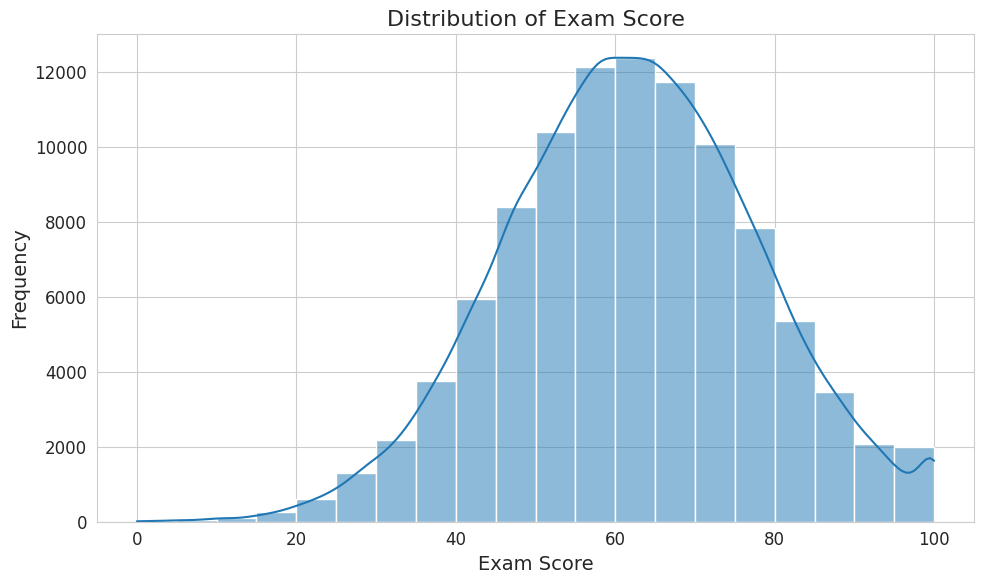

/tmp/ipykernel_4167/1119404916.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_clean[col], kde=True, bins=20, palette='viridis')


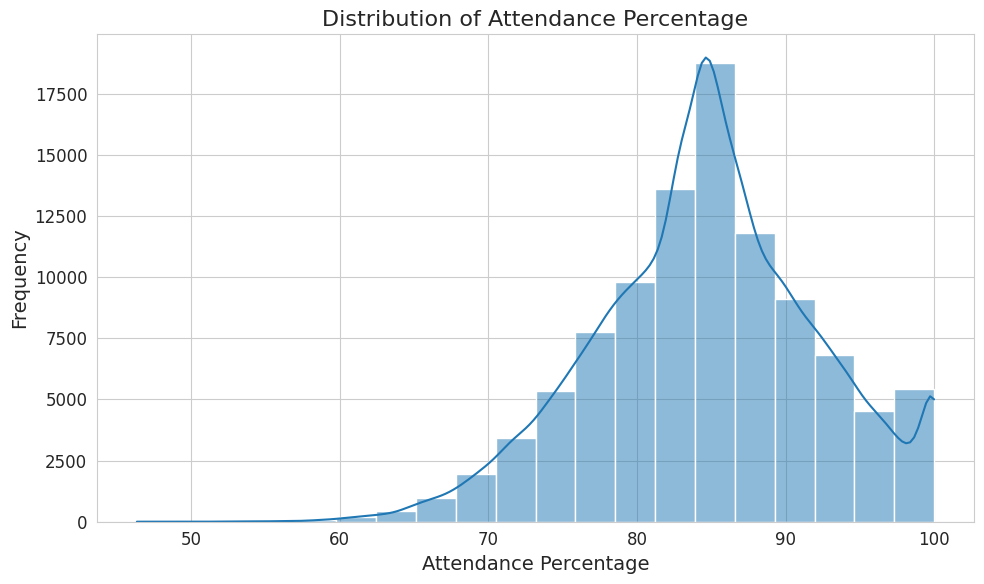

/tmp/ipykernel_4167/1119404916.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_clean[col], kde=True, bins=20, palette='viridis')


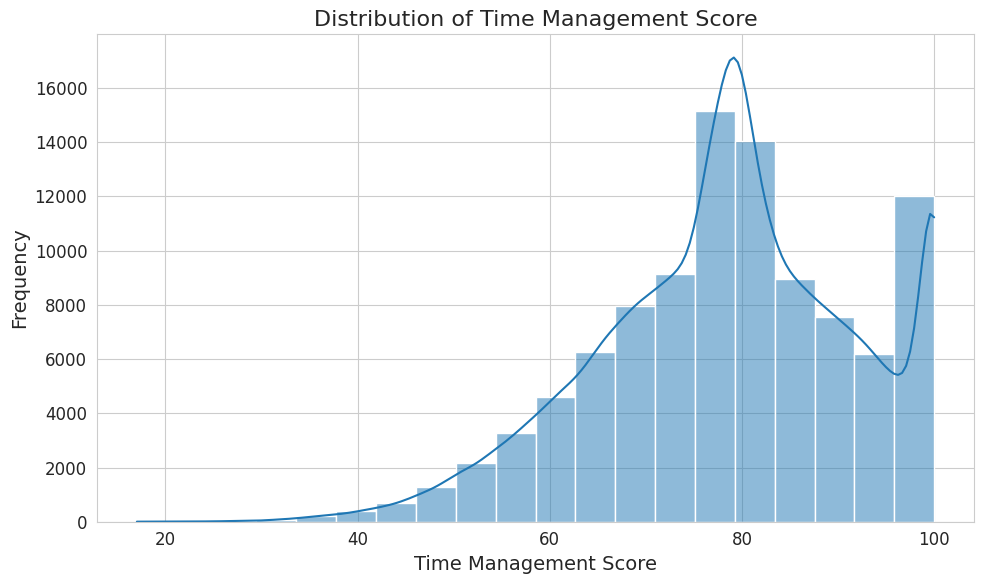


--- Generating Bar Charts ---


/tmp/ipykernel_4167/1119404916.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='cubehelix', order=df_clean[col].value_counts().index)


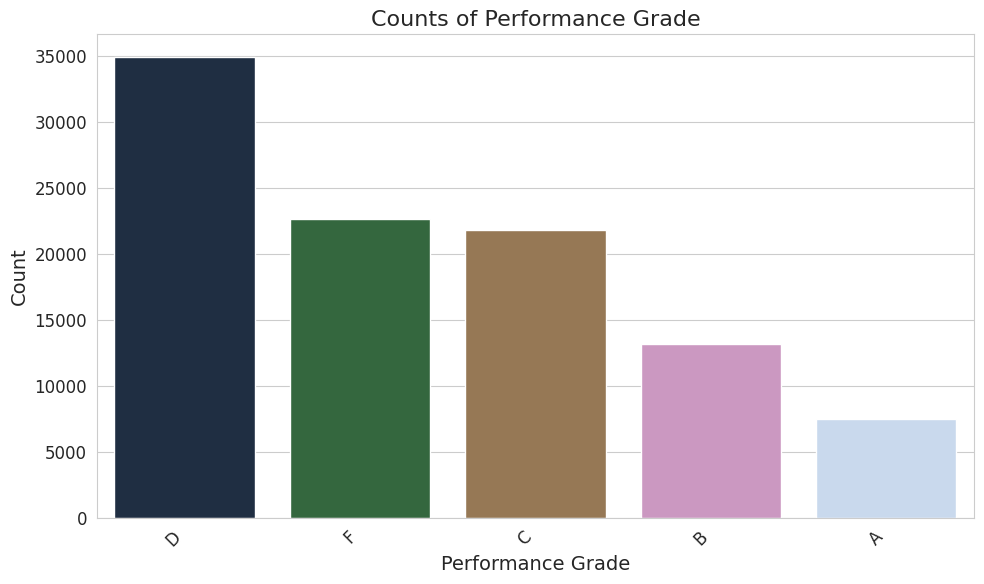

/tmp/ipykernel_4167/1119404916.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='cubehelix', order=df_clean[col].value_counts().index)


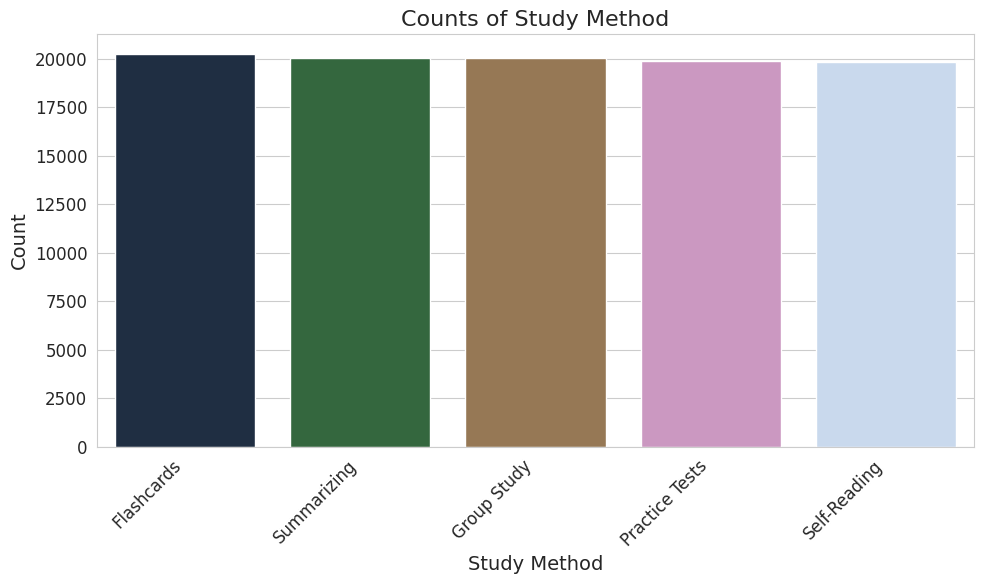


--- Generating Box Plots ---


/tmp/ipykernel_4167/1119404916.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=x_col, y=y_col, palette='coolwarm', order=df_clean[x_col].value_counts().index)


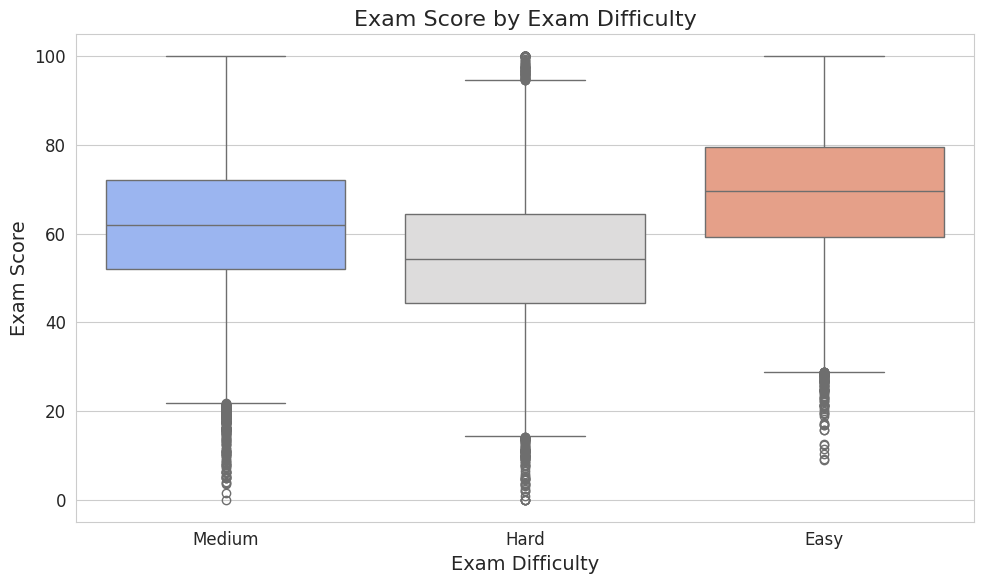

/tmp/ipykernel_4167/1119404916.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=x_col, y=y_col, palette='coolwarm', order=df_clean[x_col].value_counts().index)


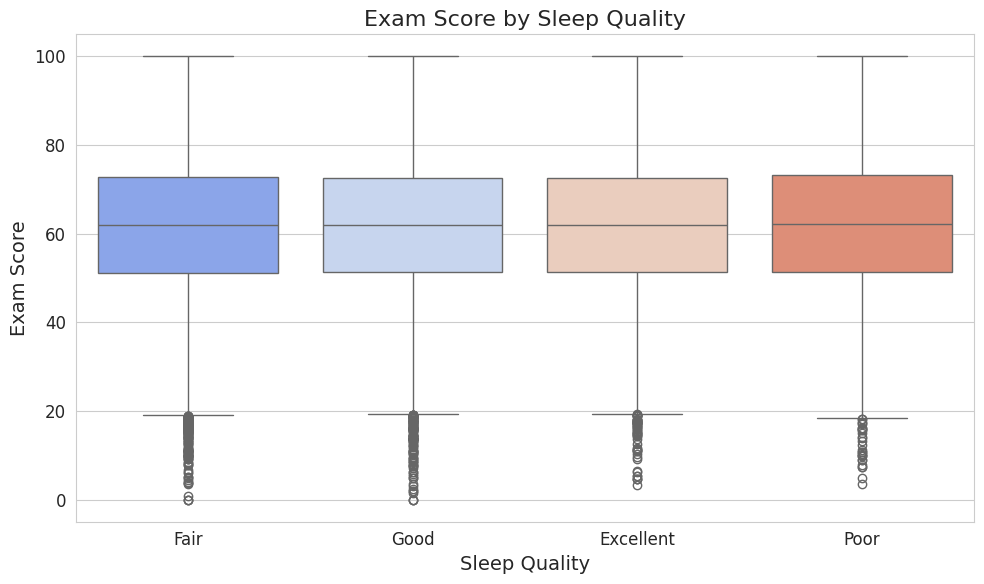


--- Generating Pie Chart ---


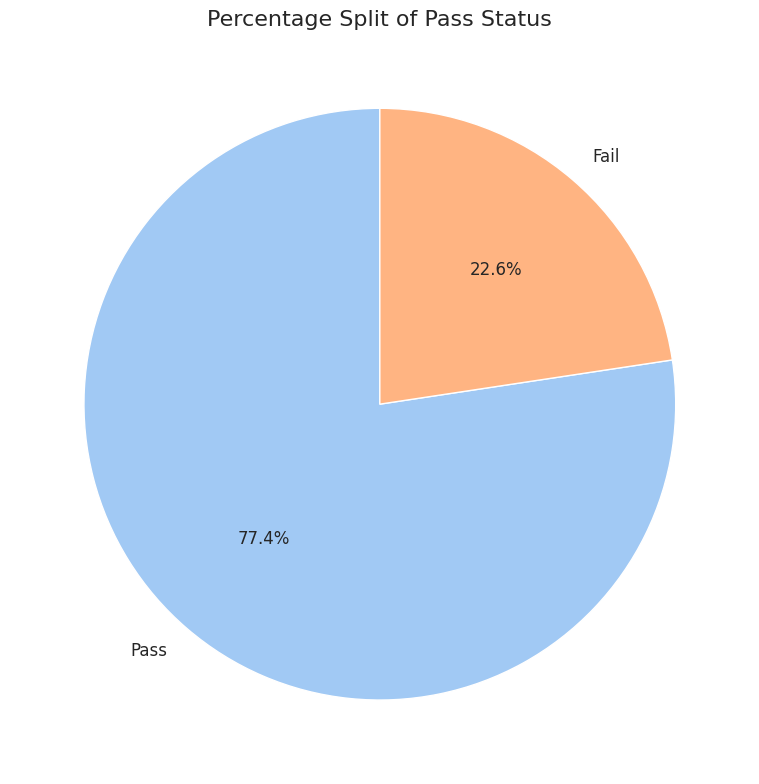


--- Generating Correlation Heatmap ---


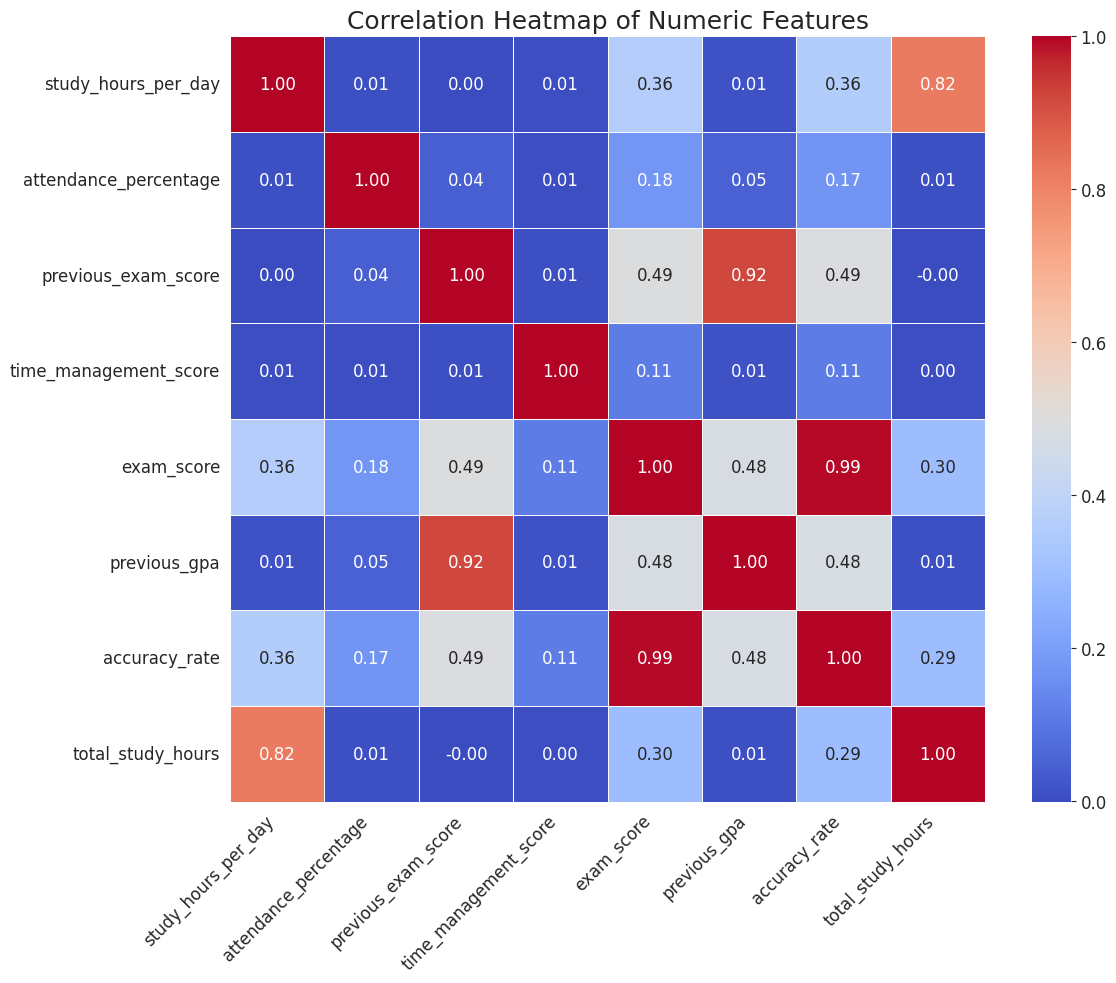

--- Data Visualization & Exploration Complete ---


In [29]:
if 'df_clean' in locals() and df_clean is not None:
    print("--- Starting Data Visualization & Exploration ---")
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['font.size'] = 12

    # 1. Histograms
    print("\n--- Generating Histograms ---")
    histogram_cols = ['exam_score', 'attendance_percentage', 'time_management_score']
    for col in histogram_cols:
        if col in df_clean.columns:
            plt.figure(figsize=(10, 6))
            sns.histplot(df_clean[col], kde=True, bins=20, palette='viridis')
            plt.title(f'Distribution of {col.replace("_", " ").title()}', fontsize=16)
            plt.xlabel(col.replace("_", " ").title(), fontsize=14)
            plt.ylabel('Frequency', fontsize=14)
            plt.tight_layout()
            plt.show()
        else:
            print(f"  - Skipping histogram for '{col}': column not found.")

    # 2. Bar Charts
    print("\n--- Generating Bar Charts ---")
    bar_chart_cols = ['performance_grade', 'study_method']
    for col in bar_chart_cols:
        if col in df_clean.columns:
            plt.figure(figsize=(10, 6))
            sns.countplot(data=df_clean, x=col, palette='cubehelix', order=df_clean[col].value_counts().index)
            plt.title(f'Counts of {col.replace("_", " ").title()}', fontsize=16)
            plt.xlabel(col.replace("_", " ").title(), fontsize=14)
            plt.ylabel('Count', fontsize=14)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
        else:
            print(f"  - Skipping bar chart for '{col}': column not found.")

    # 3. Box Plots
    print("\n--- Generating Box Plots ---")
    box_plot_pairs = [
        ('exam_difficulty', 'exam_score'),
        ('sleep_quality', 'exam_score')
    ]
    for x_col, y_col in box_plot_pairs:
        if x_col in df_clean.columns and y_col in df_clean.columns:
            plt.figure(figsize=(10, 6))
            sns.boxplot(data=df_clean, x=x_col, y=y_col, palette='coolwarm', order=df_clean[x_col].value_counts().index)
            plt.title(f'{y_col.replace("_", " ").title()} by {x_col.replace("_", " ").title()}', fontsize=16)
            plt.xlabel(x_col.replace("_", " ").title(), fontsize=14)
            plt.ylabel(y_col.replace("_", " ").title(), fontsize=14)
            plt.tight_layout()
            plt.show()
        else:
            print(f"  - Skipping box plot for '{y_col}' by '{x_col}': one or both columns not found.")

    # 4. Pie Chart
    print("\n--- Generating Pie Chart ---")
    if 'pass_status' in df_clean.columns:
        pass_status_counts = df_clean['pass_status'].value_counts()
        if not pass_status_counts.empty:
            plt.figure(figsize=(8, 8))
            plt.pie(pass_status_counts, labels=pass_status_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
            plt.title('Percentage Split of Pass Status', fontsize=16)
            plt.ylabel('') # Hide default ylabel
            plt.tight_layout()
            plt.show()
        else:
            print("  - 'pass_status' column is empty, cannot generate pie chart.")
    else:
        print("  - Skipping pie chart for 'pass_status': column not found.")

    # 5. Correlation Heatmap
    print("\n--- Generating Correlation Heatmap ---")
    numeric_features_for_corr = [
        'study_hours_per_day', 'attendance_percentage', 'previous_exam_score',
        'time_management_score', 'exam_score', 'previous_gpa', 'accuracy_rate', 'total_study_hours'
    ]
    # Filter to only include numeric columns that exist in df_clean
    existing_numeric_features = [col for col in numeric_features_for_corr if col in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[col])]

    if existing_numeric_features:
        correlation_matrix = df_clean[existing_numeric_features].corr()
        plt.figure(figsize=(12, 10))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('Correlation Heatmap of Numeric Features', fontsize=18)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print("  - No sufficient numeric features found for correlation heatmap.")

    print("--- Data Visualization & Exploration Complete ---")
else:
    print("Cleaned DataFrame (df_clean) not found. Skipping visualization.")

## Section 6: Load (L) - SQLite Database

In [30]:
if 'df_clean' in locals() and df_clean is not None:
    print("--- Starting Data Loading to SQLite Database ---")

    db_filepath = 'data/processed/student_performance.db'
    Path('data/processed').mkdir(parents=True, exist_ok=True) # Ensure directory exists

    # 1. Establish a connection to SQLite using sqlalchemy
    try:
        engine = create_engine(f'sqlite:///{db_filepath}')
        print(f"Connected to SQLite database: {db_filepath}")
    except Exception as e:
        print(f"Error connecting to database: {e}")
        engine = None

    if engine:
        # 2. Write df_clean into an SQLite table named `clean_student_performance`
        try:
            df_clean.to_sql('clean_student_performance', con=engine, if_exists='replace', index=False)
            print("DataFrame 'df_clean' successfully loaded into 'clean_student_performance' table.")

            # 3. Write an audit/metadata table `etl_log`
            # Calculate missing values resolved during transformation
            # This requires knowing initial missing counts. For this example, we'll assume df_raw.isnull().sum() provides this.
            # In a more complex ETL, you'd store initial and final missing counts explicitly.
            if 'df_raw' in locals() and df_raw is not None:
                initial_missing_count = df_raw.isnull().sum().sum()
                final_missing_count = df_clean.isnull().sum().sum() # Should be 0 if imputation was comprehensive
                missing_resolved = initial_missing_count - final_missing_count
            else:
                missing_resolved = "N/A (df_raw not available)"

            etl_log_data = {
                'timestamp': [pd.Timestamp.now()],
                'input_row_count': [df_raw.shape[0] if 'df_raw' in locals() and df_raw is not None else 'N/A'],
                'cleaned_row_count': [df_clean.shape[0]],
                'missing_values_resolved': [missing_resolved],
                'output_table_name': ['clean_student_performance']
            }
            df_etl_log = pd.DataFrame(etl_log_data)
            df_etl_log.to_sql('etl_log', con=engine, if_exists='append', index=False)
            print("ETL log successfully updated in 'etl_log' table.")

        except Exception as e:
            print(f"Error loading data to SQL table or creating ETL log: {e}")

    print("--- Data Loading to SQLite Database Complete ---")
else:
    print("Cleaned DataFrame (df_clean) not found. Skipping data loading to SQLite.")

--- Starting Data Loading to SQLite Database ---
Connected to SQLite database: data/processed/student_performance.db
DataFrame 'df_clean' successfully loaded into 'clean_student_performance' table.
ETL log successfully updated in 'etl_log' table.
--- Data Loading to SQLite Database Complete ---


## Section 7: Database Verification Via SQL Queries

In [31]:
if 'engine' in locals() and engine is not None:
    print("--- Starting Database Verification via SQL Queries ---")

    # Helper function to run and display SQL queries
    def run_sql_query(query, title="SQL Query Result"):
        print(f"\n--- {title} ---")
        try:
            df_result = pd.read_sql_query(query, engine)
            if not df_result.empty:
                print(df_result.to_markdown(index=False, numalign="left", stralign="left"))
            else:
                print("No results found for this query.")
        except Exception as e:
            print(f"Error executing query: {e}")

    # Query 1: Average exam_score and count of students grouped by performance_grade
    query_1 = """
    SELECT
        performance_grade,
        COUNT(student_id) AS student_count,
        ROUND(AVG(exam_score), 2) AS average_exam_score
    FROM clean_student_performance
    GROUP BY performance_grade
    ORDER BY average_exam_score DESC;
    """
    run_sql_query(query_1, "Query 1: Average Exam Score and Count by Performance Grade")

    # Query 2: Top 5 study methods with highest average exam_score for students with >85% attendance
    query_2 = """
    SELECT
        study_method,
        COUNT(student_id) AS student_count,
        ROUND(AVG(exam_score), 2) AS average_exam_score
    FROM clean_student_performance
    WHERE attendance_percentage > 85
    GROUP BY study_method
    ORDER BY average_exam_score DESC
    LIMIT 5;
    """
    run_sql_query(query_2, "Query 2: Top 5 Study Methods by Exam Score (High Attendance)")

    # Query 3: Pass/Fail breakdown by family_income and school_type
    query_3 = """
    SELECT
        family_income,
        school_type,
        pass_status,
        COUNT(student_id) AS student_count
    FROM clean_student_performance
    GROUP BY family_income, school_type, pass_status
    ORDER BY family_income, school_type, pass_status;
    """
    run_sql_query(query_3, "Query 3: Pass/Fail Breakdown by Family Income and School Type")

    # Query 4: Summary aggregation checking overall table row counts and schema integrity
    query_4_count = """
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT student_id) AS unique_students
    FROM clean_student_performance;
    """
    run_sql_query(query_4_count, "Query 4a: Overall Table Row Count and Unique Students")

    # Query 4b: Schema Integrity (checking a few non-null constraints implicitly via count)
    # This is a basic check. A more robust check would involve PRAGMA table_info()
    query_4_schema_check = """
    SELECT
        COUNT(CASE WHEN exam_score IS NULL THEN 1 END) AS null_exam_scores,
        COUNT(CASE WHEN performance_grade IS NULL THEN 1 END) AS null_performance_grades,
        COUNT(CASE WHEN attendance_percentage IS NULL THEN 1 END) AS null_attendance_percentages
    FROM clean_student_performance;
    """
    run_sql_query(query_4_schema_check, "Query 4b: Basic Schema Integrity (Null Counts)")

    print("--- Database Verification Complete ---")
else:
    print("Database engine not initialized. Skipping SQL queries.")

--- Starting Database Verification via SQL Queries ---

--- Query 1: Average Exam Score and Count by Performance Grade ---
| performance_grade   | student_count   | average_exam_score   |
|:--------------------|:----------------|:---------------------|
| A                   | 7519            | 91.66                |
| B                   | 13190           | 79.38                |
| C                   | 21794           | 69.74                |
| D                   | 34886           | 57.82                |
| F                   | 22611           | 40.77                |

--- Query 2: Top 5 Study Methods by Exam Score (High Attendance) ---
| study_method   | student_count   | average_exam_score   |
|:---------------|:----------------|:---------------------|
| Practice Tests | 9558            | 65.45                |
| Self-Reading   | 9580            | 65.3                 |
| Flashcards     | 9671            | 65.21                |
| Summarizing    | 9654            | 65.13          